In [9]:
# importing library 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [97]:
df = pd.read_csv("smartcart_customers.csv")

df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
657,946,1958,2n Cycle,Together,26490.0,0,0,22-09-2012,92,45,...,21,20,25,2,3,1,5,6,0,0
890,1928,1973,Graduation,Married,31814.0,1,0,09-02-2013,73,35,...,4,1,20,2,2,0,3,9,0,0
958,1523,1973,Graduation,Married,59041.0,1,1,07-05-2014,25,69,...,2,2,6,2,2,0,4,5,0,0
472,564,1981,PhD,Together,56937.0,1,0,04-08-2012,81,746,...,11,8,8,7,8,6,9,6,0,1
1697,10742,1983,PhD,Married,86580.0,0,0,27-02-2013,72,532,...,26,20,20,0,4,2,5,1,0,0


In [98]:
df.shape

(2240, 22)

In [99]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## Data Preprocessing


In [100]:
# handle missing value's by SimpleImputer

median_imputer = SimpleImputer(strategy="median")

df["Income"] = median_imputer.fit_transform(df[["Income"]])[:, 0]

df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [101]:
# feature engineering

# we have "Year_Birth" column that isn't much more meaningful but if we convert it into age of customer this will reflect more impact on our dataset

now = pd.Timestamp.now()

df["Age"] = now.year - df["Year_Birth"]
df = df.drop("Year_Birth", axis="columns")
df.sample()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
1213,697,Graduation,Together,74918.0,0,0,12-03-2013,78,972,59,...,19,59,1,5,9,6,3,0,0,57


In [102]:
# from the Date of joining of customer. we have to calculate customer tenure day by today's date 

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)
now = pd.Timestamp.now()


df["Customer_Tenure_days"] = (now - df["Dt_Customer"]).dt.days

# drop DT_customer
df = df.drop("Dt_Customer", axis="columns")


In [103]:
df.columns

Index(['ID', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome',
       'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_days'],
      dtype='object')

In [104]:
# multiple columns --> into 1
# 1. Total_Spending_On_Purchasing = (MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds)
df["Total_Spending_On_Purchasing"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
df = df.drop(["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"], axis="columns")

# 2. Total_Child = (Kidhome + Teenhome)
df["Total_Child"] = df["Kidhome"] + df["Teenhome"] 
df = df.drop(["Kidhome", "Teenhome"], axis="columns")


In [105]:
# customer id don't have any significance on data set so we will remove iter

df = df.drop("ID", axis="columns")

In [106]:
df

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_Spending_On_Purchasing,Total_Child
0,Graduation,Single,58138.0,58,3,8,10,4,7,0,1,69,5008,1617,0
1,Graduation,Single,46344.0,38,2,1,1,2,5,0,0,72,4458,27,2
2,Graduation,Together,71613.0,26,1,8,2,10,4,0,0,61,4657,776,0
3,Graduation,Together,26646.0,26,2,2,0,4,6,0,0,42,4484,53,1
4,PhD,Married,58293.0,94,5,5,3,6,5,0,0,45,4506,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduation,Married,61223.0,46,2,9,3,4,5,0,0,59,4726,1341,1
2236,PhD,Together,64014.0,56,7,8,2,5,7,0,0,80,4364,444,3
2237,Graduation,Divorced,56981.0,91,1,2,3,13,6,0,0,45,4500,1241,0
2238,Master,Together,69245.0,8,2,6,5,10,3,0,0,70,4501,843,1


In [107]:
df["Education"].value_counts()

# Graduation    1127 ---> Graduate
# PhD            486 --- 
#                       ---> PostGraduate
# Master         370 ---
# 2n Cycle       203 ---
#                       ---> UnderGraduate
# Basic           54 ---

df["Education"].replace({
    "Basic": "UnderGraduate",
    "2n Cycle": "UnderGraduate",
    "Graduation": "Graduate",
    "Master": "PostGraduate",
    "PhD": "PostGraduate"
}, inplace=True)

C:\Users\RITS\AppData\Local\Temp\ipykernel_18924\4016280148.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Education"].replace({


In [108]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [109]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

df = df.drop("Marital_Status", axis="columns")

In [110]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [111]:
df.shape
df.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_days', 'Total_Spending_On_Purchasing', 'Total_Child',
       'Living_With'],
      dtype='object')

## Outlier detection

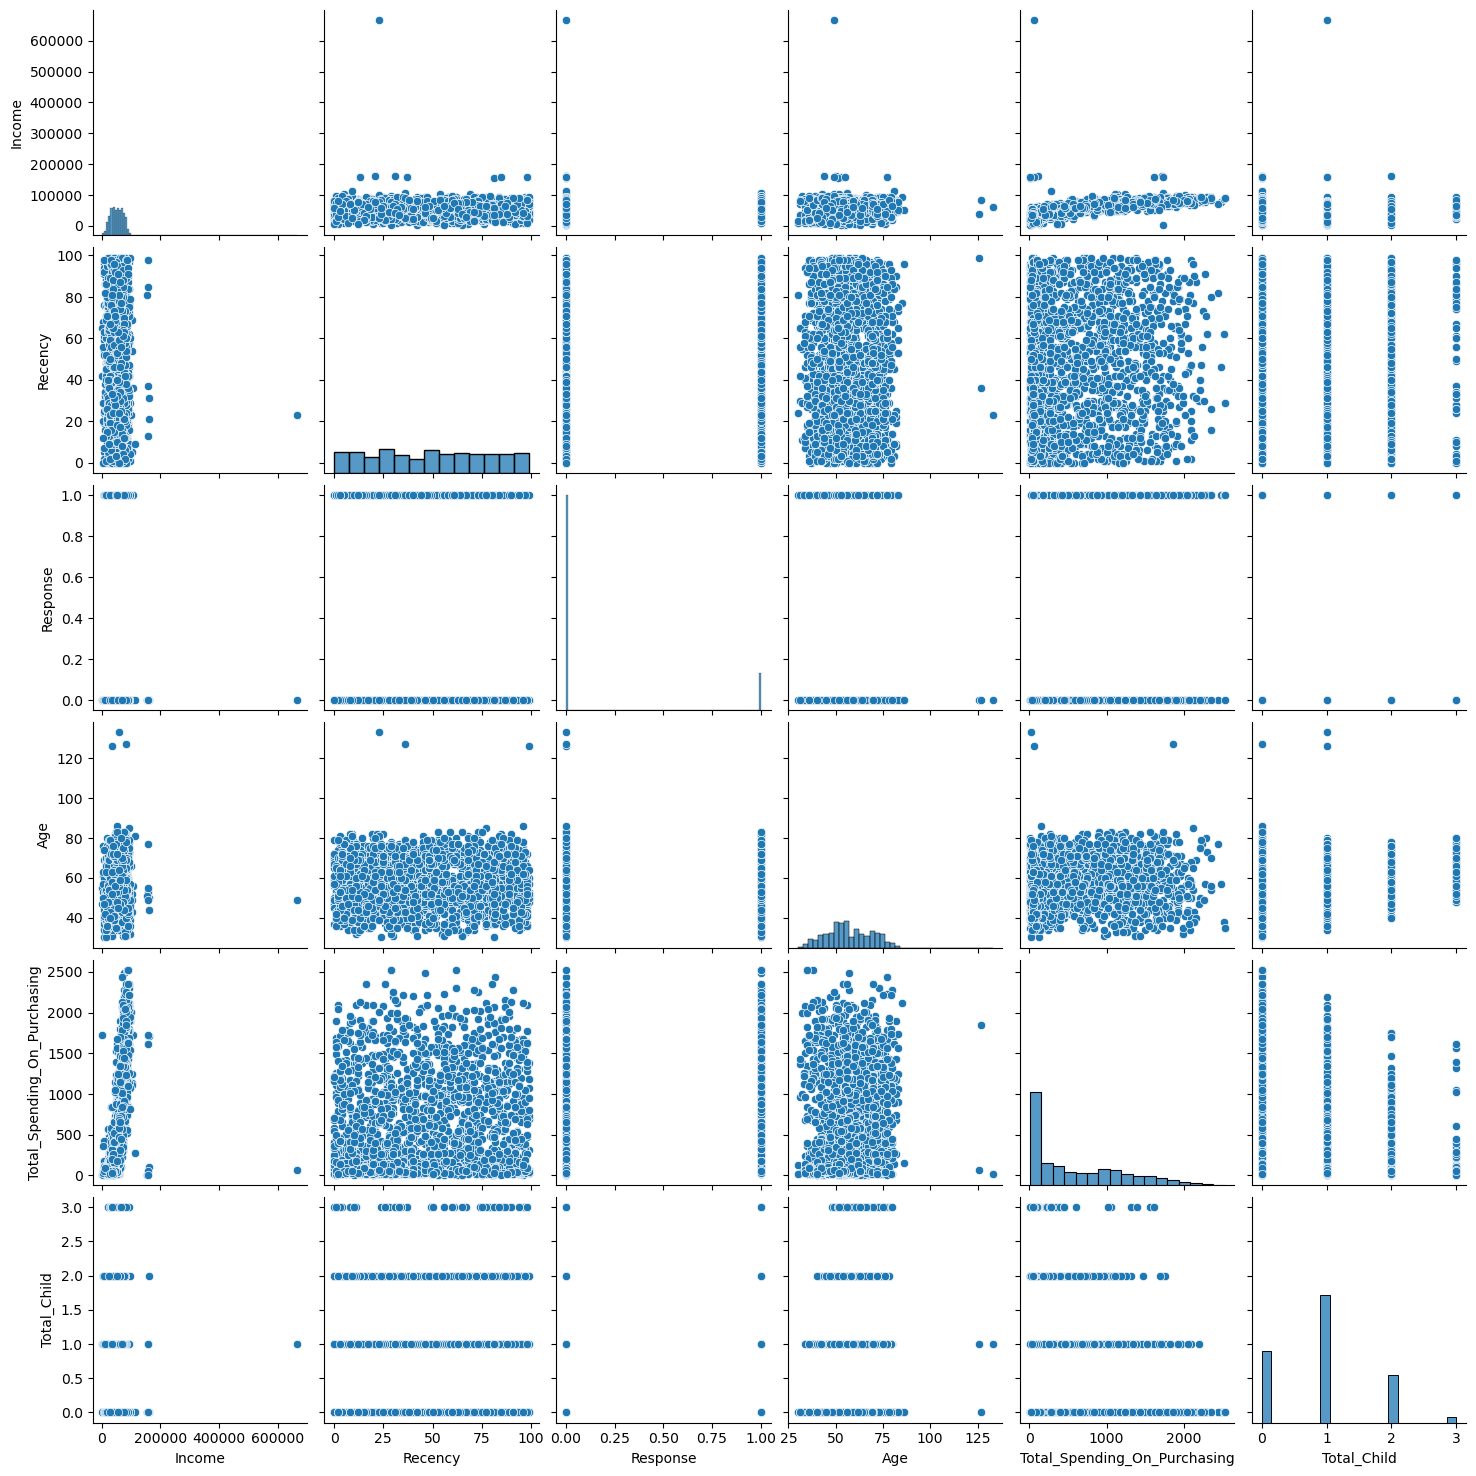

In [112]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending_On_Purchasing", "Total_Child"]

# Relative plot's of some feature:- pair plots

sns.pairplot(df[cols])

* In the income data, we observed a customer with an income of ~600,000+ this acts as 'noise' in our dataset.
* in Age there are some people with age 120+

In [113]:
# removing outlier

print(f"Data size with oulier: {len(df)}")

df = df[df["Age"] < 90]
df = df[df["Income"] < 600_000]

print(f"Data size without oulier: {len(df)}")

Data size with oulier: 2240
Data size without oulier: 2236
